# EDA: Hidden Gems Analysis

Exploratory Data Analysis to identify undervalued players (hidden gems)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Load data
df = pd.read_csv('../data/FIFA23/FIFA23_official_data.csv')
print(f"Data loaded: {df.shape[0]} players")

# Parse currency values
def parse_currency(val):
    """Convert currency strings like '€115K' to numeric values"""
    if pd.isna(val) or val == '':
        return np.nan
    val = str(val).replace('€', '').strip()
    if 'M' in val:
        return float(val.replace('M', '')) * 1_000_000
    elif 'K' in val:
        return float(val.replace('K', '')) * 1_000
    else:
        return float(val) if val else np.nan

df['wage_numeric'] = df['Wage'].apply(parse_currency)
df['value_numeric'] = df['Value'].apply(parse_currency)
print(df[['Name', 'Overall', 'Wage', 'wage_numeric', 'Club']].head())

Data loaded: 17660 players
              Name  Overall   Wage  wage_numeric               Club
0      L. Goretzka       87  €115K      115000.0  FC Bayern München
1  Bruno Fernandes       86  €190K      190000.0  Manchester United
2         M. Acuña       85   €46K       46000.0         Sevilla FC
3     K. De Bruyne       91  €350K      350000.0    Manchester City
4       N. Barella       86  €110K      110000.0              Inter


Top 15 Hidden Gems (High Rating, Low Wage):
                     Name  Age                     Position  Overall  \
7725         08 J. Micoud   33  <span class="pos pos28">SUB       84   
6333              08 Cafu   37  <span class="pos pos29">RES       83   
162      21 Santi Cazorla   35  <span class="pos pos28">SUB       82   
10704     10 F. Cannavaro   35   <span class="pos pos4">RCB       82   
724    16 Éverton Ribeiro   26  <span class="pos pos28">SUB       81   
1112         17 D. Drogba   38                          NaN       81   
383           21 M. Nérez   32    <span class="pos pos7">LB       80   
1288           A. Belotti   28  <span class="pos pos28">SUB       80   
1673         21 L. Dálves   28   <span class="pos pos24">RS       80   
2594              18 Kaká   35                          NaN       80   
11500       07 V. Candela   32   <span class="pos pos16">LM       80   
14764           T. Vaclík   33    <span class="pos pos0">GK       80   
15290            G. 

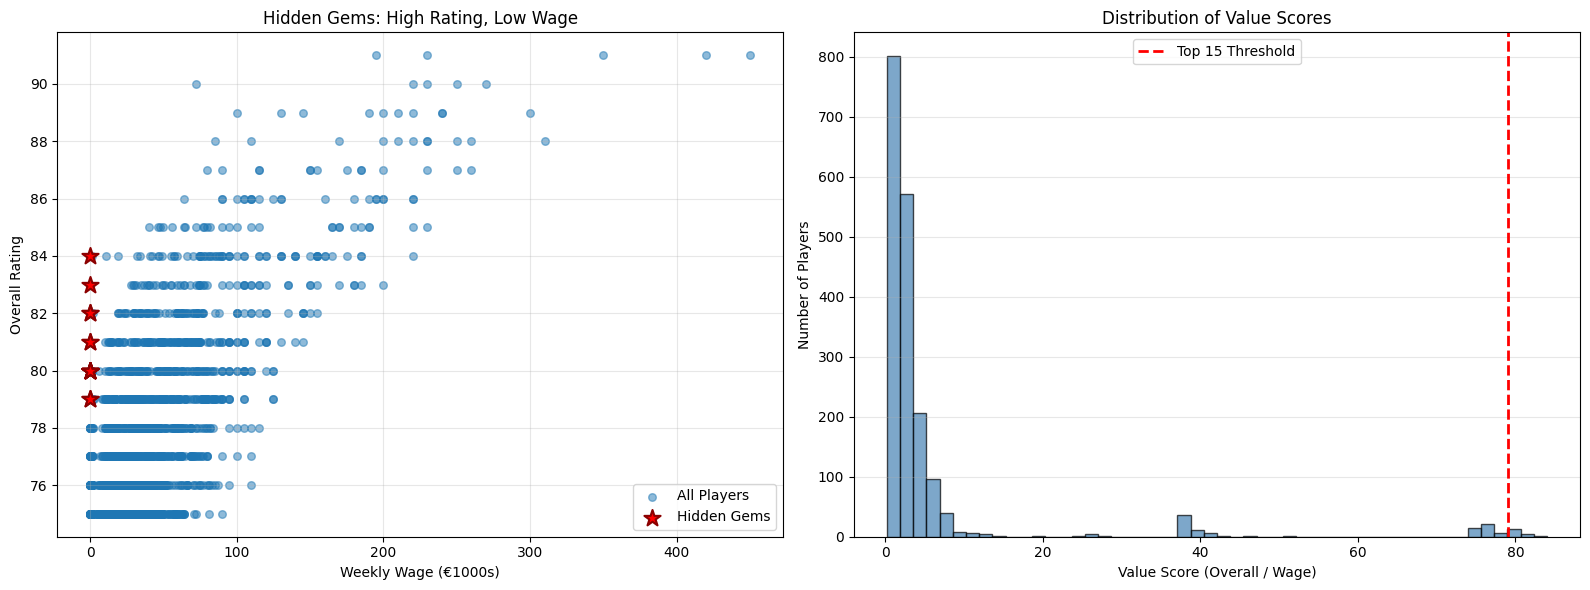

In [2]:
# Identify hidden gems: high overall rating with low wage
# Filter for players with valid wage data
df_gems = df[df['wage_numeric'].notna() & (df['Overall'] >= 75)].copy()

# Value score: overall rating per unit of wage spent
df_gems['value_score'] = df_gems['Overall'] / (df_gems['wage_numeric'] / 1000 + 1)
gems = df_gems.nlargest(15, 'value_score')[['Name', 'Age', 'Position', 'Overall', 'Club', 'wage_numeric', 'value_score']]

print('Top 15 Hidden Gems (High Rating, Low Wage):')
print(gems)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter plot: Wage vs Overall Rating
axes[0].scatter(df_gems['wage_numeric']/1000, df_gems['Overall'], alpha=0.5, s=30, label='All Players')
gems_top = df_gems.nlargest(15, 'value_score')
axes[0].scatter(gems_top['wage_numeric']/1000, gems_top['Overall'], color='red', s=150, marker='*', 
                label='Hidden Gems', zorder=5, edgecolors='darkred', linewidth=1.5)
axes[0].set_xlabel('Weekly Wage (€1000s)')
axes[0].set_ylabel('Overall Rating')
axes[0].set_title('Hidden Gems: High Rating, Low Wage')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Value Score distribution
axes[1].hist(df_gems['value_score'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[1].axvline(gems_top['value_score'].min(), color='red', linestyle='--', linewidth=2, label='Top 15 Threshold')
axes[1].set_xlabel('Value Score (Overall / Wage)')
axes[1].set_ylabel('Number of Players')
axes[1].set_title('Distribution of Value Scores')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [3]:
# Scatter: age vs potential, bubble size = value (Young undervalued gems)
young = df[df['Age'] <= 23].copy()

fig = px.scatter(
    young,
    x='Age',
    y='Potential',
    size='value_numeric',
    color='Overall',
    hover_data=['Name', 'Club', 'Nationality', 'Position'],
    color_continuous_scale='RdYlGn',
    size_max=40,
    title='Age vs Potential — Young Players (≤23)',
    labels={'Age': 'Age', 'Potential': 'Potential Rating', 'Overall': 'Current Overall', 'value_numeric': 'Market Value'},
    template='plotly_dark'
)

# Highlight the sweet spot: age ≤ 21, potential ≥ 85
fig.add_shape(type='rect', x0=15.5, x1=21.5, y0=84.5, y1=96,
              fillcolor='rgba(0,255,150,0.08)',
              line=dict(color='lime', width=1.5, dash='dot'))
fig.add_annotation(x=18.5, y=95.5, text="🎯 Hidden gems zone",
                   showarrow=False, font=dict(color='lime', size=12))

fig.update_layout(height=550)
fig.show()

# Print the actual gems: young, high potential, not yet superstars
gems = df[
    (df['Age'] <= 21) &
    (df['Potential'] >= 85) &
    (df['Overall'] < 80)
].sort_values('Potential', ascending=False)

print('\n=== TOP YOUNG GEMS (Age ≤21, Potential ≥85, Overall <80) ===')
print(gems[['Name', 'Age', 'Overall', 'Potential', 'value_numeric', 'Club', 'Position']]
      .head(15).to_string(index=False))


=== TOP YOUNG GEMS (Age ≤21, Potential ≥85, Overall <80) ===
              Name  Age  Overall  Potential  value_numeric                       Club                    Position
         Ansu Fati   19       79         90     38000000.0               FC Barcelona <span class="pos pos28">SUB
   22 M. Greenwood   19       79         90     38000000.0          Manchester United  <span class="pos pos23">RW
              Gavi   17       79         89     36000000.0               FC Barcelona <span class="pos pos28">SUB
    R. Gravenberch   20       79         89     38500000.0          FC Bayern München <span class="pos pos28">SUB
      E. Camavinga   19       79         89     38000000.0             Real Madrid CF <span class="pos pos28">SUB
   C. De Ketelaere   21       78         88     32000000.0                   AC Milan <span class="pos pos28">SUB
Gabriel Martinelli   21       78         88     31500000.0                    Arsenal  <span class="pos pos16">LM
         R. Cherki   18   